<a href="https://colab.research.google.com/github/zmzain/zmzain/blob/main/BiLSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 32.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import optuna
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional, Dense, Dropout, GlobalMaxPooling1D
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    f1_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
# -----------------------------
# 1. Load and prepare data
# -----------------------------
df = pd.read_csv("https://raw.githubusercontent.com/zmzain/zmzain/89462097da8cf598cf5e1ddfc2853c4a088f3d49/data1.csv")
texts = df["Text"].astype(str).values
labels = df["class"].values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)
num_classes = len(label_encoder.classes_)

max_words = 20000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
X_seq = tokenizer.texts_to_sequences(texts)
X_pad = pad_sequences(X_seq, maxlen=max_len, padding="post", truncating="post")
vocab_size = min(max_words, len(tokenizer.word_index) + 1)

X_train_pad, X_test_pad, y_train, y_test = train_test_split(
    X_pad, y, test_size=0.2, random_state=42, stratify=y
)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_pad, y_train, test_size=0.2, random_state=42, stratify=y_train
)

classes = np.unique(y_tr)
class_weights_array = compute_class_weight("balanced", classes=classes, y=y_tr)
class_weights = {int(c): float(w) for c, w in zip(classes, class_weights_array)}


In [4]:
# -----------------------------
# 2. BiLSTM Model Builder
# -----------------------------
def build_bilstm_model(trial, vocab_size, max_len, num_classes):
    # Hyperparameters
    embedding_dim = trial.suggest_categorical("embedding_dim", [100, 200, 300])
    lstm_units    = trial.suggest_int("lstm_units", 64, 256, step=64)
    dropout_rate  = trial.suggest_float("dropout_rate", 0.3, 0.5)
    lr            = trial.suggest_float("lr", 5e-4, 3e-3, log=True)

    model = Sequential([
        # Masking is crucial for BiLSTM to ignore the "post" padding
        Embedding(input_dim=vocab_size,
                  output_dim=embedding_dim,
                  input_length=max_len,
                  mask_zero=True),

        # Bidirectional LSTM Layer
        Bidirectional(LSTM(lstm_units, return_sequences=True, dropout=dropout_rate)),

        # Use Global Max Pooling to extract the most important features over time
        GlobalMaxPooling1D(),

        Dropout(dropout_rate),
        Dense(64, activation="relu"),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=Adam(learning_rate=lr),
        metrics=["accuracy"]
    )
    return model


In [5]:
# -----------------------------
# 3. Optuna objective
# -----------------------------
def objective(trial):
    tf.keras.backend.clear_session()
    model = build_bilstm_model(trial, vocab_size, max_len, num_classes)

    # Using more patience for BiLSTMs as they can be slower to converge
    early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=batch_size,
        callbacks=[early_stop],
        class_weight=class_weights,
        verbose=0
    )

    y_val_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    return f1_score(y_val, y_val_pred, average="macro")


In [6]:
# -----------------------------
# 4. Run Optuna study
# -----------------------------
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50) # Increased trials slightly

print(f"Best Macro F1: {study.best_value}")
print(f"Best Params: {study.best_params}")


[I 2026-05-24 00:46:30,946] A new study created in memory with name: no-name-74aa698f-d817-447d-b648-aa235557f5f4
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
[I 2026-05-24 00:47:04,059] Trial 0 finished with value: 0.7316420263777133 and parameters: {'embedding_dim': 200, 'lstm_units': 64, 'dropout_rate': 0.350900351421935, 'lr': 0.0017259608035582869, 'batch_size': 32}. Best is trial 0 with value: 0.7316420263777133.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length

Best Macro F1: 0.7393370940708044
Best Params: {'embedding_dim': 200, 'lstm_units': 256, 'dropout_rate': 0.45601302026692964, 'lr': 0.0017940049716902607, 'batch_size': 64}


In [7]:
# -----------------------------
# 5. Train Best BiLSTM on full train
# -----------------------------
tf.keras.backend.clear_session()
best_params = study.best_params
best_model = build_bilstm_model(
    optuna.trial.FixedTrial(best_params),
    vocab_size, max_len, num_classes
)

best_model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=25,
    batch_size=best_params["batch_size"],
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    class_weight=class_weights,
    verbose=1
)


Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


260/260 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.6671 - loss: 0.7603 - val_accuracy: 0.7570 - val_loss: 0.6020
Epoch 2/25
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8566 - loss: 0.3810 - val_accuracy: 0.7457 - val_loss: 0.6732
Epoch 3/25
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9388 - loss: 0.1725 - val_accuracy: 0.7435 - val_loss: 0.8129
Epoch 4/25
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9681 - loss: 0.0879 - val_accuracy: 0.7337 - val_loss: 1.3840
Epoch 5/25
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9796 - loss: 0.0590 - val_accuracy: 0.7370 - val_loss: 1.4313
Epoch 6/25
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9835 - loss: 0.0483 - val_accuracy: 0.7283 - val_loss: 1.3748


144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

--- FINAL TEST EVALUATION ---
              precision    recall  f1-score   support

    negative       0.72      0.85      0.78      1836
     neutral       0.87      0.69      0.77      2039
    positive       0.61      0.68      0.64       733

    accuracy                           0.75      4608
   macro avg       0.73      0.74      0.73      4608
weighted avg       0.77      0.75      0.75      4608

Macro Precision: 0.7339
Macro Recall:    0.7411
Macro F1-score:  0.7316


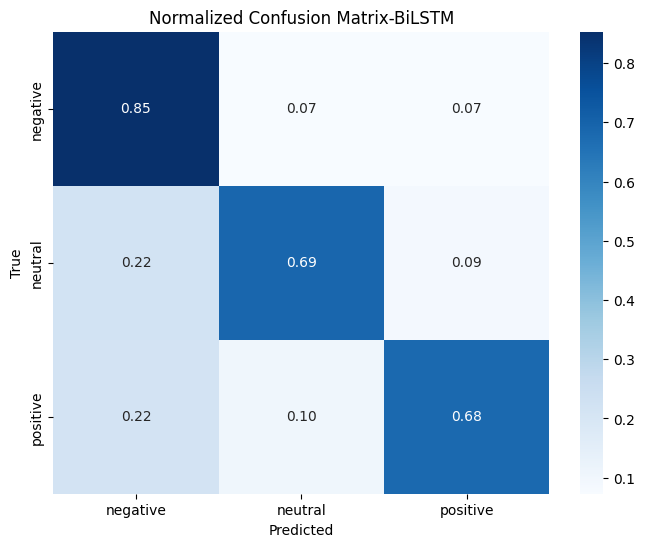

In [10]:
# -----------------------------
# 6. Evaluation
# -----------------------------
y_test_pred = np.argmax(best_model.predict(X_test_pad), axis=1)

print("\n--- FINAL TEST EVALUATION ---")
print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))
p, r, f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average="macro", zero_division=0)
print(f"Macro Precision: {p:.4f}")
print(f"Macro Recall:    {r:.4f}")
print(f"Macro F1-score:  {f1:.4f}")

# Plot Normalized Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Normalized Confusion Matrix-BiLSTM")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()